# Import

In [1]:
import sys

sys.path.append(r"D:\Materials\AI\Projects\Lib\torchwires\src")

from torchwires import Repo, Trainer,Visualizer

In [2]:
import torch
from torch.utils.data import DataLoader, Dataset

import numpy as np

# Create

In [3]:
repo = Repo(
    repo_name="full_test_1",
)

# Models

In [4]:
class LinearStack(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = torch.nn.Linear(10, 10)
        self.activation = torch.nn.ReLU()

    def forward(self, x):
        x = self.linear1(x)
        x = self.activation(x)
        return x

In [5]:
m1 = LinearStack()

repo.register_model(
    name='m1',
    model=m1
)

Model m1: has been registered
Model m1 weights loaded: path=full_test_1\exp_1\last\m1.weights.pth


In [6]:
m2 = LinearStack()

repo.register_model(
    name='m2',
    model=m2
)

Model m2: has been registered
Model m2 weights loaded: path=full_test_1\exp_1\last\m2.weights.pth


# Optimizers

In [7]:
repo.register_optimizer(
    name='m1',
    optimizer= torch.optim.Adam(m1.parameters(), lr=0.001)
)

Optimizer m1: has been registered
Optimizer m1 loaded: path=full_test_1\exp_1\last\m1.optimizer.pth


In [8]:
repo.register_optimizer(
    name='m2',
    optimizer= torch.optim.lr_scheduler.CosineAnnealingLR(
                torch.optim.Adam(m2.parameters(), lr=0.001),
                T_max=100,
    )
)

Optimizer m2: has been registered
Optimizer m2 loaded: path=full_test_1\exp_1\last\m2.optimizer.pth


# Loaders

In [9]:
class MyDataset(Dataset):
    def __init__(self):
        self.err = 0.0

    def __len__(self):
        return 30

    def __getitem__(self, index):
        x = torch.rand((10,))
        y = torch.sin(x) + self.err * torch.randn(10)
        return x, y

In [10]:
train_loader = DataLoader(
        MyDataset(),
        batch_size=2,
)

val_loader = DataLoader(
    MyDataset(),
    batch_size=2,
)

# Connections

In [11]:
repo.add_forward(
    model_name='m1',
    inputs=['x'],
    outputs=['y-intermediate'],
)

ForwardStep added: y-intermediate = m1(x)


In [12]:
repo.add_forward(
    model_name='m2',
    inputs=['y-intermediate'],
    outputs=['y-hat'],
)

ForwardStep added: y-hat = m2(y-intermediate)


# Losses & Metrics

In [13]:
repo.add_loss(
    loss_name='mae',
    loss_function=lambda s: torch.flatten(s['y-hat'] - s['y']).abs().mean(),
    weight_function=lambda s: np.random.rand()
)

LossStep added: mae


In [14]:
repo.add_metric(
    metric_name='mse',
    metric_function=lambda s: torch.flatten(s['y-hat'] - s['y']).square().mean(),
)

MetricStep added: mse


In [15]:
repo.add_metric(
    metric_name='intermediate_std',
    metric_function=lambda s: torch.flatten(s['y-hat'] - s['y']).std(),
)

MetricStep added: intermediate_std


# Load

In [16]:
repo.load()

Model m1 weights loaded: path=full_test_1\exp_1\last\m1.weights.pth
Model m2 weights loaded: path=full_test_1\exp_1\last\m2.weights.pth
Optimizer m1 loaded: path=full_test_1\exp_1\last\m1.optimizer.pth
Optimizer m2 loaded: path=full_test_1\exp_1\last\m2.optimizer.pth
History loaded: path=full_test_1\exp_1\history.json
No History Features found: path=full_test_1\exp_1\history_tracked.json


# Training

In [17]:
trainer = Trainer(
    repo=repo,
    device='cpu'
)

In [ ]:
trainer.train(
    n_epochs=100,
    train_loader=train_loader,
    val_loader=val_loader,
    loader_output_keys=['x', 'y'],
)

Training full_test_1: Starting training epoch 100 -> 100 epochs
Training full_test_1: Done


# Access Models

In [19]:
repo.get_all_models_names()

['m1', 'm2']

In [20]:
repo.get_model_node('m2').get_model()

LinearStack(
  (linear1): Linear(in_features=10, out_features=10, bias=True)
  (activation): ReLU()
)

# Save

In [21]:
repo.save()

Model m1 weights saved: path=full_test_1\exp_1\last\m1.weights.pth
Model m2 weights saved: path=full_test_1\exp_1\last\m2.weights.pth
Optimizer m1 weights saved: path=full_test_1\exp_1\last\m1.optimizer.pth
Optimizer m2 weights saved: path=full_test_1\exp_1\last\m2.optimizer.pth


In [22]:
repo.save(
    "final_dat"
)

Model m1 weights saved: path=full_test_1\exp_1\final_dat\m1.weights.pth
Model m2 weights saved: path=full_test_1\exp_1\final_dat\m2.weights.pth
Optimizer m1 weights saved: path=full_test_1\exp_1\final_dat\m1.optimizer.pth
Optimizer m2 weights saved: path=full_test_1\exp_1\final_dat\m2.optimizer.pth


# Visualize

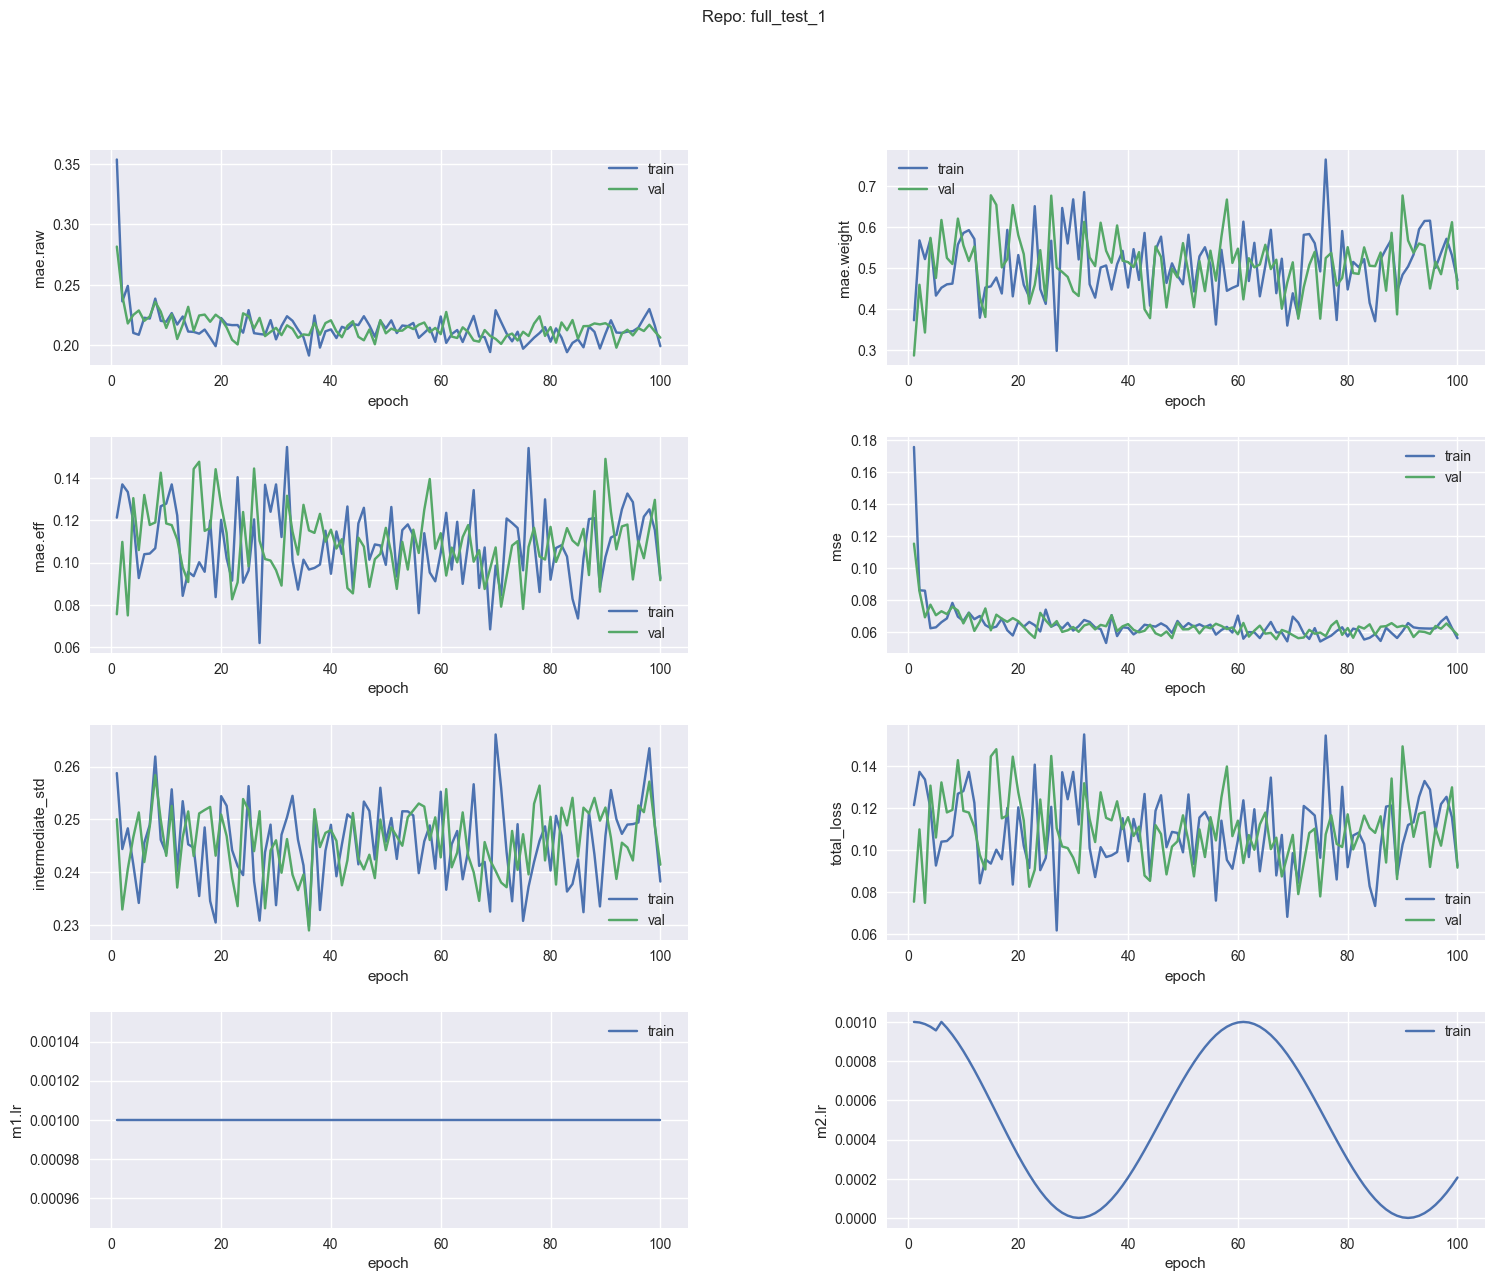

In [23]:
Visualizer.visualize_repo(
    repo,
    n_cols=2,
    cell_size=(9,7/2)
)

In [24]:
Visualizer.display_df(
    repo,
)

mae.raw  mae.weight   mae.eff       mse  intermediate_std  \
epoch loader                                                               
1     train   0.353627    0.372979  0.121320  0.175723          0.258772   
      val     0.281661    0.286977  0.075487  0.115210          0.250023   
2     train   0.236395    0.567535  0.137106  0.086024          0.244364   
      val     0.241086    0.459358  0.109812  0.085404          0.232893   
3     train   0.249165    0.521914  0.133493  0.085769          0.248286   
...                ...         ...       ...       ...               ...   
98    val     0.217074    0.547313  0.116275  0.065239          0.257157   
99    train   0.216191    0.530819  0.115446  0.062403          0.248757   
      val     0.211432    0.611840  0.129768  0.061759          0.248742   
100   train   0.199321    0.469857  0.092552  0.055983          0.238196   
      val     0.206389    0.449410  0.091647  0.058123          0.241388   

              total_loss  m1.lr     m2.lr  
epoch loader                               
1     train     0.121320  0.001  0.001000  
      val       0.075487    NaN       NaN  
2     train     0.137106  0.001  0.000997  
      val       0.109812    NaN       NaN  
3     train     0.133493  0.001  0.000989  
...                  ...    ...       ...  
98    val       0.116275    NaN       NaN  
99    train     0.115446  0.001  0.000165  
      val       0.129768    NaN       NaN  
100   train     0.092552  0.001  0.000206  
      val       0.091647    NaN       NaN  

[200 rows x 8 columns]